# Previsão de Produtividade de Safra — Modelo de Regressão

Notebook para construção de um modelo de regressão que prevê `produtividade_ton_ha` a partir das variáveis agronômicas do talhão.

## 1. Carregamento dos Dados

In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

CSV_PATH = 'base_sintetica_previsao_produtividade_safra_v2.csv'
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# Algumas colunas de texto vieram com espacos em volta (ex: ' Sul ', ' Sudeste ')
text_cols = df.select_dtypes(include=['object', 'string']).columns
for col in text_cols:
    df[col] = df[col].str.strip()

df.head()

,id_talhao,ano_safra,regiao,cultivar,tipo_solo,irrigacao,area_plantada_ha,chuva_mm,temperatura_media_c,horas_sol_dia,ph_solo,fertilizante_kg_ha,indice_pragas,densidade_plantio_mil_sementes_ha,produtividade_ton_ha
0,TAL-01199,2022,Sudeste,Cultivar A,Misto,Irrigado,14.8,1042.1,22.4,7.57,6.89,160.9,2.18,54.9,7.636
1,TAL-00527,2025,Norte,Cultivar C,ARGILOSO,Sequeiro,61.9,453.8,27.7,4.23,6.18,151.8,4.26,78.5,5.552
2,TAL-00394,2024,Centro-Oeste,Cultivar A,Argiloso,Sequeiro,34.9,748.3,23.3,8.24,5.80,153.6,2.34,35.9,8.446
3,TAL-01408,2021,Sul,Cultivar A,Arenoso,Sequeiro,38.4,929.6,20.9,7.35,4.70,205.1,3.78,67.6,7.837
4,TAL-00434,2024,Nordeste,Cultivar A,Argiloso,Irrigado,22.2,1367.7,22.6,5.61,4.91,224.4,1.53,68.5,6.756


**O que foi feito:** carregou o CSV e removeu espaços em branco acidentais nas colunas de texto
(ex: `' Sul '` vira `'Sul'`). `df.head()` mostra as 5 primeiras linhas.

**Para que serve:** primeira inspeção visual dos dados, para confirmar que a leitura do arquivo
funcionou como esperado e que as colunas fazem sentido antes de qualquer análise.

In [3]:
df.tail()

,id_talhao,ano_safra,regiao,cultivar,tipo_solo,irrigacao,area_plantada_ha,chuva_mm,temperatura_media_c,horas_sol_dia,ph_solo,fertilizante_kg_ha,indice_pragas,densidade_plantio_mil_sementes_ha,produtividade_ton_ha
2010,TAL-01131,2021,Norte,Cultivar A,Arenoso,Sequeiro,18.2,851.8,NaN,9.21,6.29,93.1,3.63,69.4,8.187
2011,TAL-01295,2022,Sudeste,Cultivar A,Misto,Sequeiro,48.1,774.2,27.7,7.67,4.95,153.2,5.09,71.8,6.842
2012,TAL-00861,2022,Centro-Oeste,Cultivar A,Argiloso,Sequeiro,94.5,710.2,NaN,7.09,6.33,134.5,1.07,51.9,4.087
2013,TAL-01460,2025,Sudeste,Cultivar B,Arenoso,Irrigado,55.7,NaN,NaN,8.61,5.83,174.9,5.35,69.0,9.300
2014,TAL-01127,2022,Centro-Oeste,Cultivar B,Argiloso,Sequeiro,98.0,874.8,23.2,4.02,5.82,238.6,0.48,85.3,9.172


**O que foi feito:** mostrou as últimas 5 linhas do dataframe (`df.tail()`).

**Para que serve:** confirmar que o arquivo foi lido até o fim sem truncamento e checar se há
alguma inconsistência perto do final da base (ex: linhas cortadas ou formatação diferente).

In [4]:
df.dtypes

id_talhao                                str
ano_safra                              int64
regiao                                   str
cultivar                                 str
tipo_solo                                str
irrigacao                                str
area_plantada_ha                     float64
chuva_mm                             float64
temperatura_media_c                  float64
horas_sol_dia                        float64
ph_solo                              float64
fertilizante_kg_ha                   float64
indice_pragas                        float64
densidade_plantio_mil_sementes_ha    float64
produtividade_ton_ha                 float64
dtype: object

**O que foi feito:** listou o tipo de dado (`dtype`) de cada coluna.

**Para que serve:** confirmar que colunas numéricas foram lidas como `int64`/`float64` e não como
texto — o que indicaria sujeira nos dados (vírgula decimal, caractere inválido, espaço) exigindo
correção com `pd.to_numeric`/`pd.to_datetime` antes de seguir.

**Variavel target:** `produtividade_ton_ha` — variavel continua numerica (ton/ha) que sera prevista pelo modelo de regressao.

## 2. Análise Exploratória (EDA)

### 2.1 Estrutura, nulos e duplicatas

In [5]:
TARGET = 'produtividade_ton_ha'

nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_tab = pd.DataFrame({'n_nulos': nulos, 'pct_nulos': nulos_pct})
print("Nulos por coluna:")
print(nulos_tab[nulos_tab['n_nulos'] > 0].sort_values('pct_nulos', ascending=False))

print(f"\nDuplicatas completas: {df.duplicated().sum()}")
print(f"Duplicatas por chave de negocio (id_talhao): {df.duplicated(subset=['id_talhao']).sum()}")

df.sample(10, random_state=42)

Nulos por coluna:
                     n_nulos  pct_nulos
indice_pragas            387      19.21
ph_solo                   86       4.27
chuva_mm                  81       4.02
temperatura_media_c       73       3.62

Duplicatas completas: 15
Duplicatas por chave de negocio (id_talhao): 15


,id_talhao,ano_safra,regiao,cultivar,tipo_solo,irrigacao,area_plantada_ha,chuva_mm,temperatura_media_c,horas_sol_dia,ph_solo,fertilizante_kg_ha,indice_pragas,densidade_plantio_mil_sementes_ha,produtividade_ton_ha
1198,TAL-01592,2021,Sul,Cultivar A,Misto,Irrigado,21.0,1477.7,24.2,7.08,6.25,339.7,3.51,65.0,7.523
526,TAL-01759,2021,Nordeste,Cultivar C,Arenoso,Sequeiro,51.4,1344.1,20.1,6.53,6.58,255.8,1.68,72.9,5.255
393,TAL-00618,2024,Sudeste,Cultivar C,Argiloso,Irrigado,8.4,1208.0,20.9,7.38,6.91,193.7,4.03,66.9,6.348
1407,TAL-00499,2024,Sudeste,Cultivar C,Misto,Sequeiro,54.5,664.8,22.1,6.50,5.35,184.8,2.99,60.0,7.092
433,TAL-00889,2025,Sul,Cultivar A,Argiloso,Sequeiro,207.5,645.2,22.5,8.30,6.39,134.0,1.61,63.8,8.279
1720,TAL-01634,2022,Centro-Oeste,Cultivar A,Arenoso,Sequeiro,33.0,1010.9,24.1,7.32,6.54,256.0,3.91,57.3,8.635
1090,TAL-00048,2025,Sudeste,Cultivar B,Arenoso,Sequeiro,63.0,643.4,23.6,6.11,6.86,115.7,2.28,79.0,8.065
429,TAL-01694,2021,Centro-Oeste,Cultivar B,Misto,Sequeiro,37.2,1312.4,24.8,5.89,6.32,244.2,5.13,53.5,7.939
1799,TAL-00796,2024,Sudeste,Cultivar B,Arenoso,Sequeiro,4.5,589.3,24.9,7.55,6.40,132.7,5.40,67.9,8.137
530,TAL-01582,2021,Sudeste,Cultivar B,Argiloso,Irrigado,28.3,1147.7,19.0,7.85,5.90,205.2,NaN,58.8,7.965


**O que foi feito:** calculou nulos por coluna (contagem e %), contou duplicatas completas e
duplicatas pela chave de negócio (`id_talhao`), e mostrou uma amostra aleatória de 10 linhas.

**Para que serve:** decidir estratégia de tratamento de dados faltantes (imputar, criar flag de
ausência, etc.), identificar erros de exportação/duplo lançamento (as 15 duplicatas), e olhar uma
fatia aleatória da base (fora da ordem original do arquivo) para pegar inconsistências que
`head()`/`tail()` sozinhos não mostrariam.

### 2.2 Análise do Target (`produtividade_ton_ha`)

=== Estatisticas descritivas ===
count    2015.000000
mean        7.512174
std         1.219194
min         2.856000
25%         6.756500
50%         7.599000
75%         8.325500
max        10.679000
Name: produtividade_ton_ha, dtype: float64

Media: 7.5122
Mediana: 7.5990
Desvio-padrao: 1.2192
Coef. de variacao: 0.1623

Skew (assimetria): -0.4656
Kurtosis: 0.3226

=== Valores negativos / impossiveis ===
Valores <= 0: 0
Valores negativos: 0
Valores nulos: 0


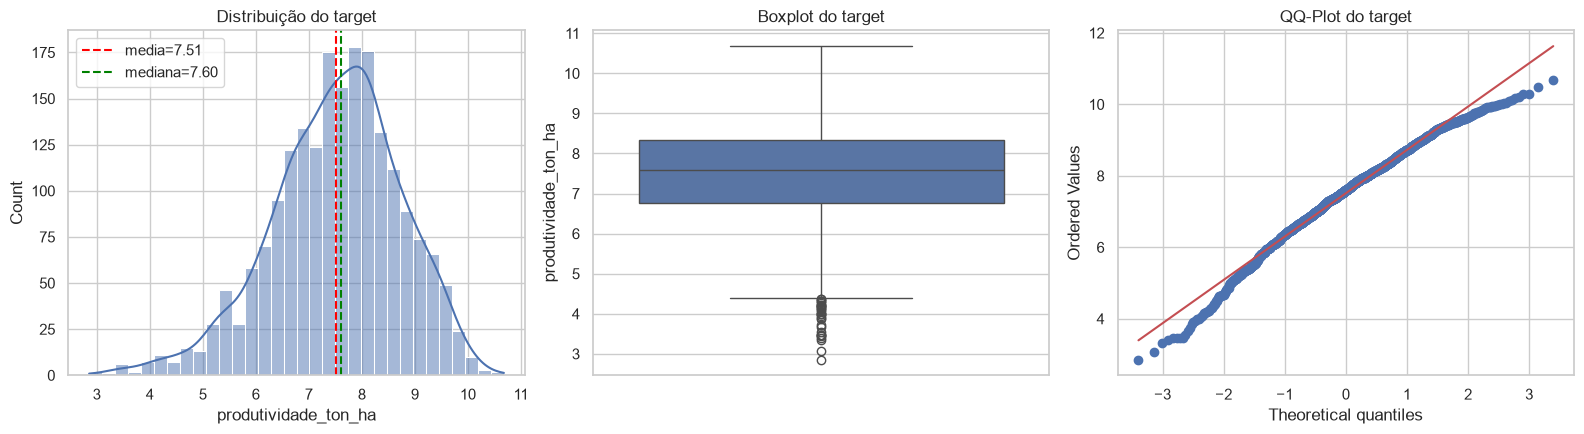


Shapiro-Wilk: estatistica=0.9869, p-valor=0.000000
=> Rejeita H0 (nao normal) a 5%

=== Avaliacao de transformacao ===
original   | skew=-0.4656 | shapiro p=0.000000
log        | skew=-1.1386 | shapiro p=0.000000
sqrt       | skew=-0.7730 | shapiro p=0.000000
box-cox    | skew=-0.0257 | shapiro p=0.033901

Box-Cox lambda estimado: 1.8665


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot, boxcox

sns.set_theme(style='whitegrid')
s = df[TARGET]

# --- Estatisticas descritivas ---
print("=== Estatisticas descritivas ===")
print(s.describe())
print(f"\nMedia: {s.mean():.4f}")
print(f"Mediana: {s.median():.4f}")
print(f"Desvio-padrao: {s.std():.4f}")
print(f"Coef. de variacao: {s.std() / s.mean():.4f}")

# --- Assimetria e curtose ---
print(f"\nSkew (assimetria): {s.skew():.4f}")
print(f"Kurtosis: {s.kurtosis():.4f}")

# --- Valores negativos ou impossiveis ---
print("\n=== Valores negativos / impossiveis ===")
print(f"Valores <= 0: {(s <= 0).sum()}")
print(f"Valores negativos: {(s < 0).sum()}")
print(f"Valores nulos: {s.isnull().sum()}")

# --- Histograma, boxplot e QQ-Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(s, kde=True, ax=axes[0])
axes[0].axvline(s.mean(), color='red', linestyle='--', label=f'media={s.mean():.2f}')
axes[0].axvline(s.median(), color='green', linestyle='--', label=f'mediana={s.median():.2f}')
axes[0].set_title('Distribuição do target')
axes[0].legend()

sns.boxplot(y=s, ax=axes[1])
axes[1].set_title('Boxplot do target')

probplot(s, plot=axes[2])
axes[2].set_title('QQ-Plot do target')

plt.tight_layout()
plt.show()

# --- Teste de normalidade (Shapiro-Wilk) ---
stat, p = shapiro(s.sample(min(5000, len(s)), random_state=42))
print(f"\nShapiro-Wilk: estatistica={stat:.4f}, p-valor={p:.6f}")
print('=> ' + ('Rejeita H0 (nao normal) a 5%' if p < 0.05 else 'Nao rejeita H0 (compativel com normal) a 5%'))

# --- Avaliacao de necessidade de transformacao (log, sqrt, Box-Cox) ---
print("\n=== Avaliacao de transformacao ===")
log_s = np.log(s[s > 0])
sqrt_s = np.sqrt(s[s >= 0])
bc_s, bc_lambda = boxcox(s[s > 0])

for nome, serie in [('original', s), ('log', log_s), ('sqrt', sqrt_s), ('box-cox', pd.Series(bc_s))]:
    sk = serie.skew()
    st, pv = shapiro(serie.sample(min(5000, len(serie)), random_state=42))
    print(f"{nome:10s} | skew={sk:7.4f} | shapiro p={pv:.6f}")

print(f"\nBox-Cox lambda estimado: {bc_lambda:.4f}")

**O que foi feito:** análise completa da variável target (`produtividade_ton_ha`) — estatísticas
descritivas, skew/kurtosis, checagem de valores negativos/impossíveis, histograma + boxplot +
QQ-plot, teste de normalidade de Shapiro-Wilk, e comparação de transformações (log, sqrt, Box-Cox).

**Para que serve:** entender a forma da distribuição do target antes de modelar — se há outliers,
se a assimetria é um problema, se o teste de normalidade e o QQ-plot concordam, e se alguma
transformação melhoraria o comportamento do target para os modelos (a conclusão logo abaixo
explica por que optamos por não transformar).

**Decisão:** o target não tem valores negativos ou impossíveis (mínimo > 0), a assimetria é leve
(skew ≈ -0.47) e o QQ-plot fica razoavelmente próximo da reta — log e sqrt pioram a assimetria
(o desvio aqui é à esquerda, não à direita) e Box-Cox só corrige o skew com um lambda próximo de 2
(quase um termo quadrático), o que sugere que não há uma transformação simples que valha a pena.
Vamos seguir sem transformar o target, e reavaliar apenas se os resíduos do modelo final
mostrarem heterocedasticidade clara.

### 2.3 Análise de Variáveis Numéricas

=== Estatisticas descritivas (variaveis numericas) ===
                                    count        mean         std     min      25%     50%      75%      max
area_plantada_ha                   2015.0   54.020149   62.898211    2.20   19.400   35.00    65.15   900.00
chuva_mm                           1934.0  874.147053  267.084890  150.00  699.225  873.30  1048.80  1686.90
temperatura_media_c                1942.0   24.168692    3.198111   13.60   22.100   24.10    26.30    34.20
horas_sol_dia                      2015.0    7.076799    1.422859    1.82    6.070    7.09     8.06    11.35
ph_solo                            1929.0    6.009990    0.604230    4.09    5.590    6.00     6.42     8.13
fertilizante_kg_ha                 2015.0  190.336030  141.120469    0.00  142.400  182.70   223.85  3048.00
indice_pragas                      1628.0    2.893839    1.614766    0.10    1.660    2.69     3.94     8.25
densidade_plantio_mil_sementes_ha  2015.0   65.086501   11.089580   27.40

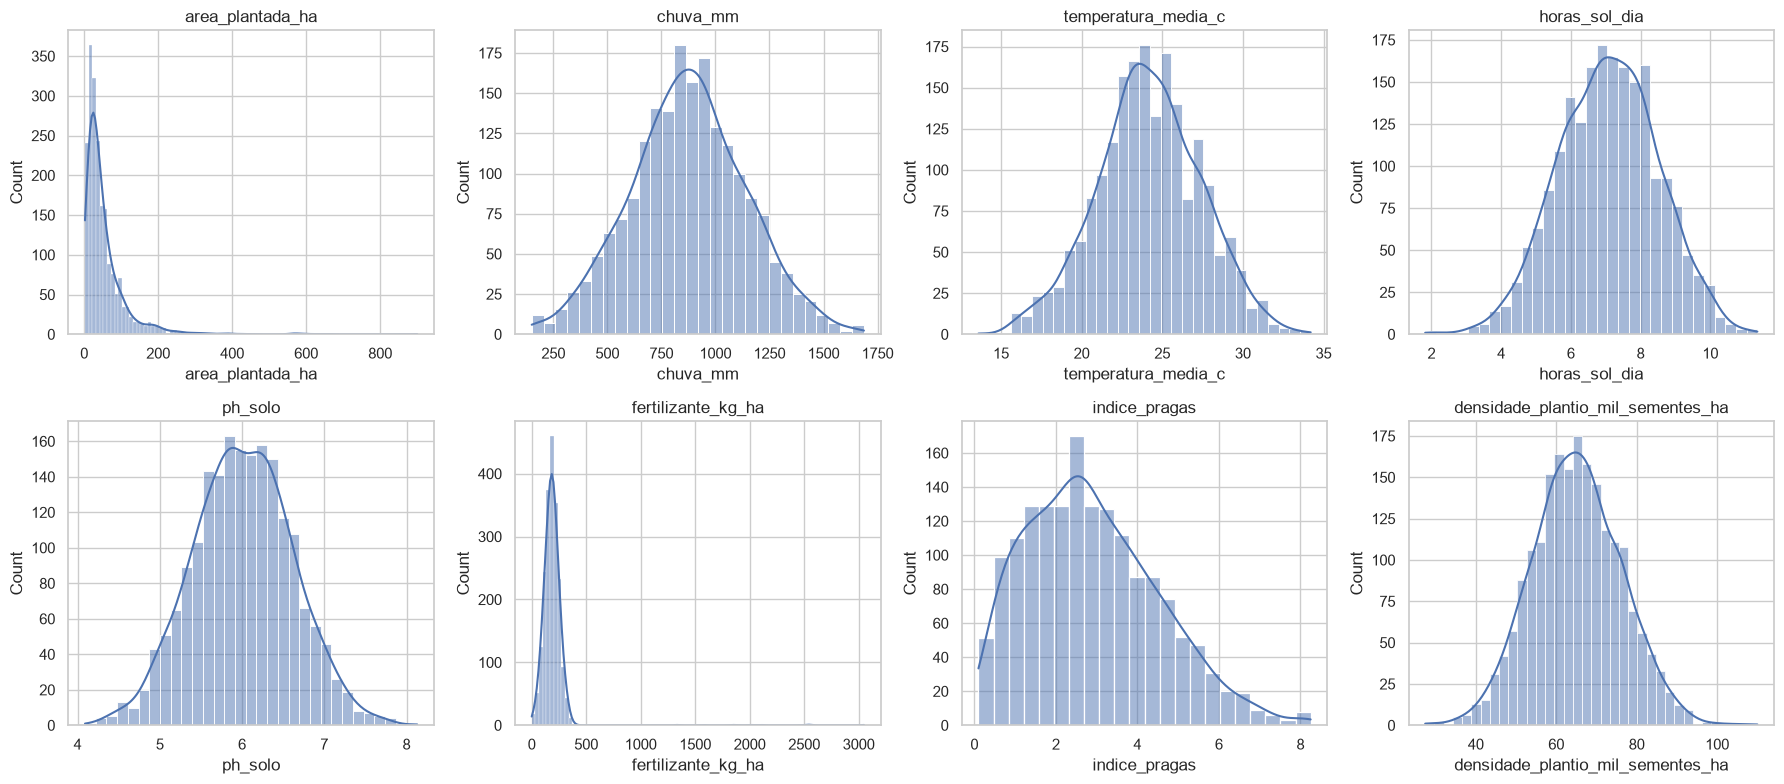

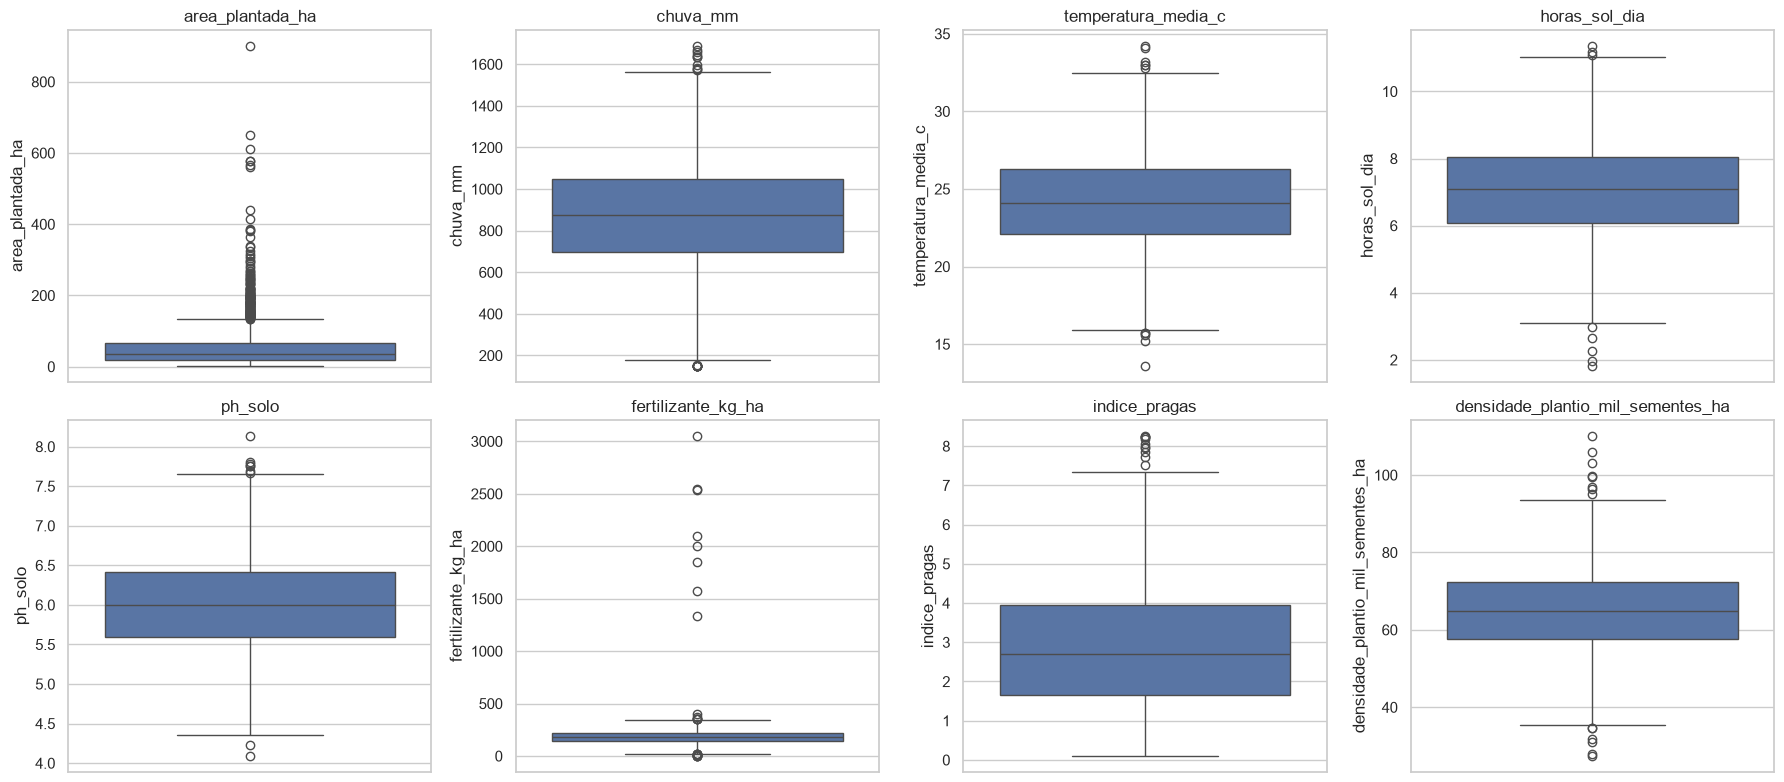


=== Checagem de ranges por conhecimento de dominio ===
area_plantada_ha                      : OK
chuva_mm                              : OK
temperatura_media_c                   : OK
horas_sol_dia                         : OK
ph_solo                               : OK
fertilizante_kg_ha                    : OK
indice_pragas                         : OK
densidade_plantio_mil_sementes_ha     : OK


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Rede de seguranca: se as celulas da Fase 1 nao foram executadas antes desta
# (ex: rodando celula por celula em vez de "Run All"), df/TARGET nao existiriam
# ainda -- recarregamos aqui em vez de deixar a celula quebrar com NameError.
if 'df' not in dir():
    CSV_PATH = 'base_sintetica_previsao_produtividade_safra_v2.csv'
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.strip()
    for col in df.select_dtypes(include=['object', 'string']).columns:
        df[col] = df[col].str.strip()
    print("(df nao estava definido; recarregado agora a partir do CSV)\n")

num_cols = ['area_plantada_ha', 'chuva_mm', 'temperatura_media_c', 'horas_sol_dia',
            'ph_solo', 'fertilizante_kg_ha', 'indice_pragas', 'densidade_plantio_mil_sementes_ha']

# --- Estatisticas descritivas ---
print("=== Estatisticas descritivas (variaveis numericas) ===")
print(df[num_cols].describe().T)

# --- Skew (assimetria) ---
skew_tab = df[num_cols].skew().sort_values(key=abs, ascending=False)
print("\n=== Skew (assimetria) por feature ===")
print(skew_tab)

# --- Variancia zero ou quase zero ---
var_tab = df[num_cols].var().sort_values()
print("\n=== Variancia por feature ===")
print(var_tab)
quase_zero = var_tab[var_tab < 1e-3]
if len(quase_zero) > 0:
    print(f"\n[ALERTA] Features com variancia ~zero (candidatas a remover): {quase_zero.index.tolist()}")
else:
    print("\nNenhuma feature com variancia zero/quase-zero encontrada -- nenhuma remocao necessaria.")

# --- Escala muito diferente entre features ---
escala_tab = df[num_cols].agg(['min', 'max']).T
escala_tab['range'] = escala_tab['max'] - escala_tab['min']
print("\n=== Range (min/max) por feature -- para identificar diferenca de escala ===")
print(escala_tab.sort_values('range', ascending=False))

# --- Histograma de cada feature ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# --- Boxplot de cada feature ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# --- Ranges esperados / valores impossiveis por conhecimento de dominio ---
print("\n=== Checagem de ranges por conhecimento de dominio ===")
checagens = {
    'area_plantada_ha': (df['area_plantada_ha'] <= 0).sum(),
    'chuva_mm': (df['chuva_mm'] < 0).sum(),
    'temperatura_media_c': ((df['temperatura_media_c'] < -10) | (df['temperatura_media_c'] > 45)).sum(),
    'horas_sol_dia': ((df['horas_sol_dia'] < 0) | (df['horas_sol_dia'] > 24)).sum(),
    'ph_solo': ((df['ph_solo'] < 0) | (df['ph_solo'] > 14)).sum(),
    'fertilizante_kg_ha': (df['fertilizante_kg_ha'] < 0).sum(),
    'indice_pragas': (df['indice_pragas'] < 0).sum(),
    'densidade_plantio_mil_sementes_ha': (df['densidade_plantio_mil_sementes_ha'] <= 0).sum(),
}
for col, n in checagens.items():
    status = 'OK' if n == 0 else f'[ALERTA] {n} valor(es) fora do range esperado'
    print(f"{col:38s}: {status}")

**O que foi feito:** para cada feature numérica (excluindo `id_talhao` e o target) — estatísticas
descritivas, skew, variância (para achar features quase constantes), range min/max (para comparar
escalas), histograma, boxplot, e uma checagem de valores fora do fisicamente possível (ex: chuva
negativa, pH fora de 0–14, horas de sol acima de 24/dia).

**Para que serve:** decidir se alguma feature precisa ser removida por não carregar informação
(variância ~zero), se o escalonamento (`StandardScaler`) será necessário antes de modelos
sensíveis a escala (regressão linear, KNN, SVR), e se há erros de digitação/captura que precisam
de correção antes de seguir para modelagem — modelos de árvore não exigem escalonamento, mas os
lineares e baseados em distância sim.